In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#modeling
from sklearn.metrics import mean_squared_error, root_mean_squared_error, accuracy_score, mean_absolute_error, precision_score, recall_score, r2_score, confusion_matrix
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [2]:
#read data
df = pd.read_csv('data/stud.csv')
print(df.shape)
df.head(5)

(1002, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
# Choose X & Y
x= df.drop(columns=['math_score'])
y= df['math_score']
print(x)
print(y)

      gender race_ethnicity parental_level_of_education         lunch  \
0     female        group B           bachelor's degree      standard   
1     female        group C                some college      standard   
2     female        group B             master's degree      standard   
3       male        group A          associate's degree  free/reduced   
4       male        group C                some college      standard   
...      ...            ...                         ...           ...   
997   female        group C                 high school  free/reduced   
998   female        group D                some college      standard   
999   female        group D                some college  free/reduced   
1000  female        group D                some college  free/reduced   
1001    male        group C                 high school  free/reduced   

     test_preparation_course  reading_score  writing_score  
0                       none             72             74  
1

In [ ]:
'''
    1) Apply encoding to transform categorical data to numerical data of x
    2) We apply one hot encoding because not much categories we have. in case of large no. of category we would apply TargetEncoder
    3) After encoding data is converted into 1 & 0 , we need to apply standard scaling to convert other data in similar fashion, so that all the dat can be treated failrly & combine all data back
    4) to achive 3, we are using columnTransformer which automates the process by creating a pipeling
'''
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

encoding_transformer = OneHotEncoder()
scalar_transformer = StandardScaler()

#print(x,y)
categorical_col = x.select_dtypes(include="object").columns
numerical_col = x.select_dtypes(exclude="object").columns
#print(numerical_col)

preprocessing = ColumnTransformer(
    [
        ("OneHotEncoder", encoding_transformer, categorical_col),
        ("StandardScaler", scalar_transformer, numerical_col)
    ]
)




C:\Users\AnshuSrivastava\AppData\Local\Temp\ipykernel_27816\4155211320.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = x.select_dtypes(include="object").columns


In [25]:
X = preprocessing.fit_transform(x)
#print(X)

# divide data into train & test
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.3, random_state=42)

print(X_train.shape)

(300, 19)


In [31]:
# added method to evaluate

def evaluate_model(y_true, y_predicted):
    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    r2Score = r2_score(y_true, y_predicted)
    rmse = root_mean_squared_error(y_true, y_predicted)

    return mae, mse, r2Score



In [32]:
# prepare model list 
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list  = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 28.4045
- Mean Absolute Error: 4.2174
- R2 Score: 0.8627
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 28.8903
- Mean Absolute Error: 4.2994
- R2 Score: 0.8789


Lasso
Model performance for Training set
- Root Mean Squared Error: 45.7541
- Mean Absolute Error: 5.3648
- R2 Score: 0.7789
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 44.1118
- Mean Absolute Error: 5.2551
- R2 Score: 0.8151


Ridge
Model performance for Training set
- Root Mean Squared Error: 28.4275
- Mean Absolute Error: 4.2186
- R2 Score: 0.8626
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 28.7537
- Mean Absolute Error: 4.2850
- R2 Score: 0.8795


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 36.0855
- Mean Absolute Error: 4.7700
- R2 Score: 0.8256
----------------

In [ ]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

#Here Linear Regression has high R2 score so will go with this

,Model Name,R2_Score
2,Ridge,0.879454
0,Linear Regression,0.878882
7,CatBoosting Regressor,0.833811
5,Random Forest Regressor,0.833431
1,Lasso,0.815068
8,AdaBoost Regressor,0.809059
6,XGBRegressor,0.793846
3,K-Neighbors Regressor,0.772439
4,Decision Tree,0.673672


In [34]:
#Implement Linear Regression
lin_model = LinearRegression(fit_intercept=True)
lin_model = model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 81.66


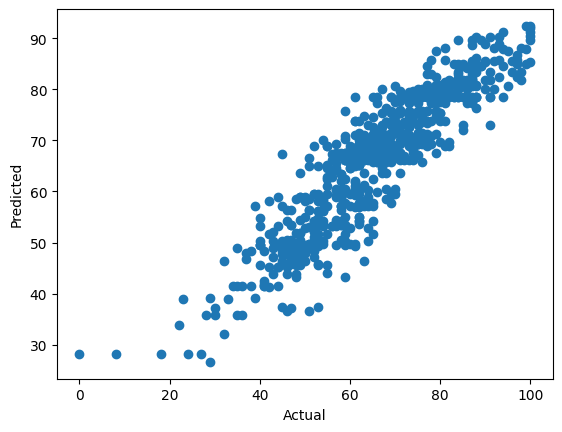

In [36]:
#validate linearity with actual & predicted
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

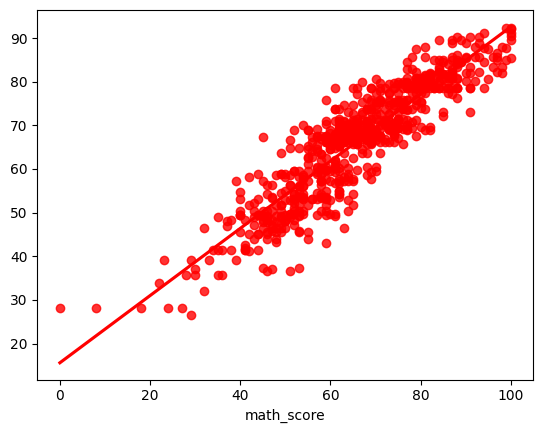

In [37]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [38]:
#check error (actual - predicted)
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df.head(5)

,Actual Value,Predicted Value,Difference
521,91,73.068966,17.931034
739,61,60.258333,0.741667
823,71,79.666667,-8.666667
662,55,65.191304,-10.191304
411,84,81.450000,2.550000
